# Singular Value Decomposition (SVD) Implementation

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand SVD fundamentals and mathematical basis
- Implement SVD in Python using NumPy
- Apply SVD for matrix decomposition, data compression, and noise reduction
- Analyze properties and importance of SVD
- Compare SVD with PCA in data analysis

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 05 "CNN for Image Classification" — an image is a matrix of pixels, and SVD is how you compress exactly such a matrix.

---

This notebook covers practical activities from **Course 03, Unit 4**:
- Applying SVD for matrix decomposition, data compression, and noise reduction
- Comparing SVD and PCA in data analysis

---

## Introduction

**Singular Value Decomposition (SVD)** is a fundamental matrix factorization technique that decomposes any matrix into three matrices, revealing the underlying structure of the data.


---

## 📌 Real case: matching documents that share no words

In 1990 Scott Deerwester, Susan Dumais, George Furnas, Thomas Landauer and Richard Harshman published
**"Indexing by Latent Semantic Analysis"** (*Journal of the American Society for Information Science*,
41(6)). The problem they attacked is now called the vocabulary mismatch: a document about *cars* and a
query about *automobiles* share no terms, so a keyword index scores them as unrelated. Their solution is
the operation in this notebook. Build a terms × documents matrix, take its **truncated SVD**, and keep a
small number of singular triplets — the 1990 paper decomposed its matrix into "ca. 100 orthogonal
factors". Words that appear in similar contexts collapse onto nearby directions in
that reduced space, so *car* and *automobile* end up close together — never having been told they are
synonyms. Truncated SVD of a sparse term-document matrix is still what `TruncatedSVD` does in
scikit-learn today, and it is the direct ancestor of the embedding methods in Course 07.

**What goes wrong without this.** Full-rank data treats every direction as equally real, including the
directions that are pure noise or pure vocabulary accident. Truncating to the top k singular values is a
principled statement — the Eckart–Young theorem, this notebook's reference 1 — that among all rank-k
matrices, this one is the closest to your data. The information you discard is the smallest you could have
discarded for that budget.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib plus sklearn's TruncatedSVD and two REAL datasets -
# handwritten digits (a real image matrix) and the wine cultivar measurements.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_digits, load_wine
from sklearn.preprocessing import StandardScaler

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")


✅ Libraries imported!


## Part 1: Understanding SVD Fundamentals

SVD decomposes a matrix A into: A = U × Σ × V^T


In [2]:
# A REAL data matrix, not a random one: 100 scanned handwritten digits, each an 8x8
# image flattened into 64 pixel intensities (0-16). Every row is something a person wrote.

digits = load_digits()
A = digits.data[:100]

print("=" * 60)
print("SVD Fundamentals")
print("=" * 60)
print(f"Data: sklearn digits - {A.shape[0]} images x {A.shape[1]} pixels")
print(f"Original matrix A shape: {A.shape}")

# Compute SVD
U, s, Vt = np.linalg.svd(A, full_matrices=False)

# Create diagonal matrix from singular values
Sigma = np.diag(s)

print(f"\nU shape: {U.shape} (left singular vectors)")
print(f"Σ (Sigma) shape: {Sigma.shape} (singular values)")
print(f"V^T shape: {Vt.shape} (right singular vectors)")

# Verify decomposition: A = U x Sigma x V^T
A_reconstructed = U @ Sigma @ Vt
reconstruction_error = np.linalg.norm(A - A_reconstructed)

print(f"\nReconstruction error: {reconstruction_error:.2e}")
print(f"✅ SVD decomposition successful! (error ≈ 0)")

print(f"\nSingular values: {s[:5].round(2)} ... (showing first 5 of {len(s)})")
print(f"They fall away fast - s[0]/s[9] = {s[0] / s[9]:.1f}x - because real digit images")
print("share a lot of structure. That decay is what makes the next cell work.")


SVD Fundamentals
Data: sklearn digits - 100 images x 64 pixels
Original matrix A shape: (100, 64)

U shape: (100, 64) (left singular vectors)
Σ (Sigma) shape: (64, 64) (singular values)
V^T shape: (64, 64) (right singular vectors)

Reconstruction error: 1.45e-12
✅ SVD decomposition successful! (error ≈ 0)

Singular values: [520.99 145.41 137.63 115.73 108.34] ... (showing first 5 of 64)
They fall away fast - s[0]/s[9] = 9.4x - because real digit images
share a lot of structure. That decay is what makes the next cell work.


## Part 2: SVD for Data Compression

Use SVD to compress data while preserving most information.


In [3]:
# Rebuild the matrix from only its top-k singular triplets and measure what compression costs.
# Because singular values are sorted by importance, a few of them carry most of the information.

# SVD for compression: Keep only top k singular values
k = 3  # Keep top 3 components

# Slice all three factors down to rank k.
U_k = U[:, :k]
Sigma_k = Sigma[:k, :k]
Vt_k = Vt[:k, :]

A_compressed = U_k @ Sigma_k @ Vt_k

# Storage: three small factors instead of the full matrix; 'information' = share of squared singular values.
compression_ratio = (U_k.size + Sigma_k.size + Vt_k.size) / A.size
info_retained = (s[:k]**2).sum() / (s**2).sum()

print("=" * 60)
print("SVD for Data Compression")
print("=" * 60)
print(f"Original matrix size: {A.size} elements ({A.shape[0]} real images x {A.shape[1]} pixels)")
print(f"Compressed representation: {U_k.size + Sigma_k.size + Vt_k.size} elements")
print(f"Compression ratio: {compression_ratio:.2%}")
print(f"Information retained: {info_retained:.2%}")

# How far is the rank-k reconstruction from the original?
reconstruction_error_compressed = np.linalg.norm(A - A_compressed)
print(f"Reconstruction error (k={k}): {reconstruction_error_compressed:.4f}")

print("\n✅ SVD allows compression while preserving most information!")
print(f"   Read it as: store {compression_ratio:.1%} of the numbers, keep {info_retained:.1%}")
print("   of the squared signal - on genuine handwriting, not a made-up matrix.")


SVD for Data Compression
Original matrix size: 6400 elements (100 real images x 64 pixels)
Compressed representation: 501 elements
Compression ratio: 7.83%
Information retained: 80.56%
Reconstruction error (k=3): 274.1561

✅ SVD allows compression while preserving most information!
   Read it as: store 7.8% of the numbers, keep 80.6%
   of the squared signal - on genuine handwriting, not a made-up matrix.


## Part 3: SVD vs PCA Comparison

Compare SVD and PCA for dimensionality reduction.


In [4]:
# Cross-check SVD against PCA on the same REAL dataset - for centered data they are near-twins.
# TruncatedSVD earns its keep on sparse matrices, where PCA's centering step would destroy sparsity.

from sklearn.decomposition import PCA

# Real dataset: 178 wine samples from three cultivars grown in the same region of Italy,
# 13 chemical measurements each (alcohol, magnesium, proline, ...).
wine = load_wine()
X = StandardScaler().fit_transform(wine.data)   # standardized => also centered
y = wine.target

# Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Apply SVD (TruncatedSVD is similar to PCA for centered data)
svd = TruncatedSVD(n_components=3, random_state=0)
X_svd = svd.fit_transform(X)

print("=" * 60)
print("SVD vs PCA Comparison")
print("=" * 60)
print(f"Dataset: wine cultivars - {X.shape[0]} samples, {X.shape[1]} chemical measurements")
print(f"Original data shape: {X.shape}")
print(f"PCA reduced shape: {X_pca.shape}")
print(f"SVD reduced shape: {X_svd.shape}")

print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")
print("They agree to the last digit - because we standardized, the data was already centered.")

# Now show what centering was doing: repeat on the RAW, uncentered wine measurements.
pca_raw = PCA(n_components=3).fit(wine.data)
svd_raw = TruncatedSVD(n_components=3, random_state=0).fit(wine.data)
print(f"\nOn the RAW (uncentered) measurements:")
print(f"  PCA explained variance: {pca_raw.explained_variance_ratio_.sum():.4%}")
print(f"  SVD explained variance: {svd_raw.explained_variance_ratio_.sum():.4%}")
print("  Both look near-perfect here only because one raw feature (proline, in the")
print("  hundreds) dwarfs the rest - a reminder to scale before you trust either number.")

print("\n✅ Key Differences:")
print("  - PCA centers the data first (subtracts the mean)")
print("  - TruncatedSVD factorises the matrix as given, centered or not")
print("  - For centered data, PCA = SVD")
print("  - SVD is more general and applicable to sparse matrices")


SVD vs PCA Comparison
Dataset: wine cultivars - 178 samples, 13 chemical measurements
Original data shape: (178, 13)
PCA reduced shape: (178, 3)
SVD reduced shape: (178, 3)

PCA explained variance: 66.53%
SVD explained variance: 66.53%
They agree to the last digit - because we standardized, the data was already centered.

On the RAW (uncentered) measurements:
  PCA explained variance: 99.9922%
  SVD explained variance: 99.9906%
  Both look near-perfect here only because one raw feature (proline, in the
  hundreds) dwarfs the rest - a reminder to scale before you trust either number.

✅ Key Differences:
  - PCA centers the data first (subtracts the mean)
  - TruncatedSVD factorises the matrix as given, centered or not
  - For centered data, PCA = SVD
  - SVD is more general and applicable to sparse matrices


## Part 4: SVD for Noise Reduction

Real data is often "low-rank signal + noise". The small singular values mostly capture the noise, so truncating them can **denoise** a matrix: reconstruct with only the top k singular values and compare against the clean signal.

SVD for Noise Reduction

Clean data: (200, 64) real handwritten-digit images
Noise added: Gaussian, sd = 5.0 on a 0-16 intensity scale

Singular values of the noisy matrix (first 8): [734.8 223.2 204.  191.4 171.1 163.8 138.7 132.7]
  -> a few dominate (real image structure); the long tail is mostly noise

Error vs the clean images BEFORE denoising: 567.7

  k   ||reconstruction - clean||   change
   1                    490.6    -13.6%
   3                    425.2    -25.1%
   5                    376.5    -33.7%
   9                    349.0    -38.5%
  15                    394.0    -30.6%
  25                    456.2    -19.6%
  64                    567.7     -0.0%

Best k in this sweep: 9
Error reduced by 38.5%


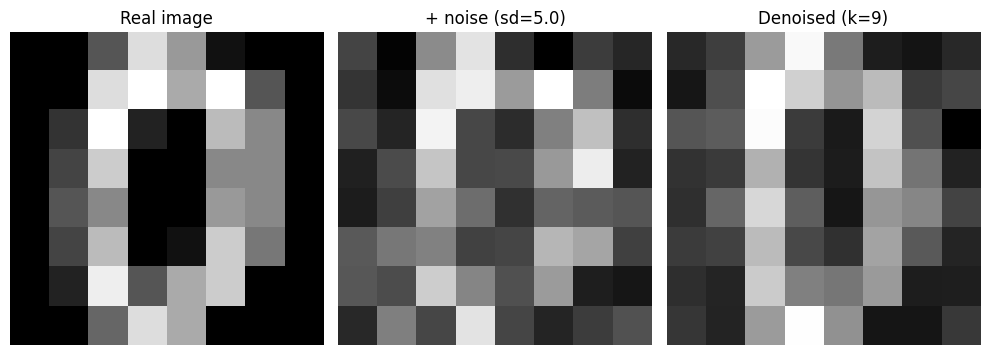


✅ Truncating small singular values removed noise - the reconstruction is CLOSER to the real images!

Note the shape of the table: too small a k throws away real handwriting, too large a k
keeps the noise. On real data the best rank is something you tune, not something you know.


In [5]:
# Denoising demo on REAL images: take 200 genuine handwritten digits, corrupt them with
# measurement noise we add on purpose, then keep only the top-k singular triplets.
# (The randomness here is the NOISE we inject to demonstrate the technique - the underlying
#  data is real. Truncated SVD works as a filter because real image structure concentrates
#  in the large singular values while noise spreads thinly across all of them.)

rng = np.random.default_rng(42)

print("=" * 60)
print("SVD for Noise Reduction")
print("=" * 60)

A_clean = digits.data[:200]                      # 200 real 8x8 digit images
noise_sd = 5.0                                   # pixel intensities run 0-16
A_noisy = A_clean + noise_sd * rng.normal(size=A_clean.shape)

print(f"\nClean data: {A_clean.shape} real handwritten-digit images")
print(f"Noise added: Gaussian, sd = {noise_sd} on a 0-16 intensity scale")

# Truncated SVD of the NOISY matrix
U_n, s_n, Vt_n = np.linalg.svd(A_noisy, full_matrices=False)
err_noisy = np.linalg.norm(A_noisy - A_clean)

print(f"\nSingular values of the noisy matrix (first 8): {np.round(s_n[:8], 1)}")
print("  -> a few dominate (real image structure); the long tail is mostly noise")

# Real data has no exact rank, so k is a choice. Sweep it and look at the truth.
print(f"\nError vs the clean images BEFORE denoising: {err_noisy:.1f}")
print("\n  k   ||reconstruction - clean||   change")
errors = {}
for k in [1, 3, 5, 9, 15, 25, 64]:
    A_k = U_n[:, :k] @ np.diag(s_n[:k]) @ Vt_n[:k, :]
    errors[k] = np.linalg.norm(A_k - A_clean)
    print(f"  {k:2d}   {errors[k]:22.1f}   {(errors[k] / err_noisy - 1) * 100:+6.1f}%")

k_best = min(errors, key=errors.get)
A_denoised = U_n[:, :k_best] @ np.diag(s_n[:k_best]) @ Vt_n[:k_best, :]
err_denoised = errors[k_best]

print(f"\nBest k in this sweep: {k_best}")
print(f"Error reduced by {(1 - err_denoised / err_noisy) * 100:.1f}%")

# Show it: original, noisy, denoised - for one real digit.
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, mat, title in zip(axes,
                          [A_clean[0], A_noisy[0], A_denoised[0]],
                          ["Real image", f"+ noise (sd={noise_sd})", f"Denoised (k={k_best})"]):
    ax.imshow(mat.reshape(8, 8), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

if err_denoised < err_noisy:
    print("\n✅ Truncating small singular values removed noise - the reconstruction is CLOSER to the real images!")
else:
    print("\n⚠️ Denoising did not help here - try a different k")

print("\nNote the shape of the table: too small a k throws away real handwriting, too large a k")
print("keeps the noise. On real data the best rank is something you tune, not something you know.")


---

## ⚠️ Where this breaks

- **"99.99% variance explained" on raw data is a trap, and this notebook prints it.** Part 3 runs the
  comparison twice. On standardized wine measurements, PCA and SVD both report 66.53% for three components.
  On the *raw* measurements both report over 99.99% — because one feature (proline, measured in the
  hundreds) dwarfs the other twelve. The number is arithmetically correct and tells you nothing except
  which column has the largest units.
- **The best truncation rank is tuned, not known.** The denoising sweep is the honest picture: error against
  the clean images falls from 567.7 to 490.6 at k = 1, bottoms out at **k = 9 (−38.5%)**, and then climbs
  back to 394.0 at k = 15 and 456.2 at k = 25. Too small a k throws away real handwriting; too large a k
  keeps the noise. There is no formula that hands you 9 — and in a real problem you do not have the clean
  images to compare against, which is the whole difficulty.
- **Compression is measured in squared signal, not in what you can see.** k = 3 stores 7.83% of the numbers
  and retains 80.56% of the squared signal — but the reconstruction error is 274.16 on a 0–16 intensity
  scale, which is visible damage. "Percent of variance retained" and "still recognisable" are different
  questions, and only one of them is answered by the singular values.
- **SVD is linear.** It finds the best low-rank *linear* approximation. If your data lies on a curved
  surface, the best rank-k plane through it may be a poor description no matter how you choose k — that is
  what notebook 05 is for.


---

## 💬 Discuss

1. The denoising sweep found k = 9 best only because we still had the clean images to compare against.
   In a real denoising job you never do. Propose a concrete way to choose k without the answer key, and
   say how it could mislead you.
2. Latent Semantic Analysis matched *car* and *automobile* without a dictionary, by discarding information.
   How is throwing information away able to *add* meaning? Explain it in terms of what the small singular
   values contain.
3. k = 3 keeps 80.6% of the squared signal and produces visibly damaged digits. If a client specifies
   "compress our scanned archive but keep it readable", what would you measure, and what would you refuse
   to promise?


## Summary

### Key Concepts:
1. **SVD Decomposition**: A = U × Σ × V^T
   - U: Left singular vectors
   - Σ: Singular values (diagonal matrix)
   - V^T: Right singular vectors

2. **Data Compression**: Keep top k singular values to compress data
3. **Noise Reduction**: Remove small singular values to reduce noise
4. **SVD vs PCA**: 
   - SVD works on raw matrices
   - PCA requires centered data
   - For centered data, PCA ≈ SVD

### Applications:
- **Image Compression**: Reduce storage while preserving quality
- **Recommendation Systems**: Matrix factorization for collaborative filtering
- **Noise Reduction**: Remove noise by truncating small singular values
- **Dimensionality Reduction**: Reduce dimensions while preserving information

**Reference:** Course 03, Unit 4: "Dimensionality Reduction and Data Representation Techniques" - SVD practical content


## 📚 References

1. Eckart, C., & Young, G. (1936). *The Approximation of One Matrix by Another of Lower Rank*. Psychometrika, 1(3), 211–218.
2. Golub, G., & Kahan, W. (1965). *Calculating the Singular Values and Pseudo-Inverse of a Matrix*. SIAM Journal on Numerical Analysis, Series B, 2(2), 205–224.
3. Halko, N., Martinsson, P.-G., & Tropp, J. A. (2011). *Finding Structure with Randomness: Probabilistic Algorithms for Constructing Approximate Matrix Decompositions*. SIAM Review, 53(2), 217–288. <https://arxiv.org/abs/0909.4061>
4. Wang, X., Zheng, Y., Wan, Z., & Zhang, M. (2024). *SVD-LLM: Truncation-aware Singular Value Decomposition for Large Language Model Compression*. arXiv. <https://arxiv.org/abs/2403.07378> — truncated SVD used to compress a large language model: this notebook's decomposition, at production scale.
5. Pearce, K. J., & Martinsson, P.-G. (2025). *Randomized Algorithms for Low-Rank Matrix and Tensor Decompositions*. arXiv. <https://arxiv.org/abs/2512.05286> — how low-rank decompositions are computed when the matrix will not fit in memory.
